<a href="https://colab.research.google.com/github/ChiaraTagiullo/olympic-power-structure/blob/main/Data_Preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Olympic Power Structure — Data Preparation

In this notebook, I prepare the Olympic dataset for the final data storytelling project.

## Goal
Transform the raw athlete-level Olympic dataset into a clean country-year dataset that can be used for visualization and storytelling.

## Main preparation steps
- import the Excel file
- inspect the structure of the dataset
- isolate medal-winning records
- avoid double-counting team medals
- aggregate medals by country and year
- export a clean dataset for later analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving ds proj.xlsx to ds proj.xlsx


In [3]:
file_name = "ds proj.xlsx"
xls = pd.ExcelFile(file_name)

print("Sheets found in the Excel file:")
print(xls.sheet_names)

Sheets found in the Excel file:
['athlete_events', 'Foglio1']


## 2. Load the main worksheet

The worksheet `athlete_events` contains the Olympic observations at athlete-event level.

In [4]:
df = pd.read_excel(file_name, sheet_name="athlete_events")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (271116, 15)


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


## 3. Inspect the raw dataset

Each row represents one athlete participating in one Olympic event.

At this stage, I inspect:
- the variables available
- their data types
- missing values

In [5]:
print("Columns:")
print(df.columns.tolist())

Columns:
['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [7]:
df.isna().sum().sort_values(ascending=False)

,0
Medal,231333
Weight,62875
Height,60171
Age,9474
Sex,0
ID,0
Name,0
Team,0
NOC,0
Year,0


## 4. Initial interpretation of missing values

The missing values are concentrated in athlete-specific variables such as `Age`, `Height`, and `Weight`, and especially in `Medal`.

This is expected:
- most athletes do not win a medal, so `Medal` is missing for a large number of rows
- some athlete characteristics are incomplete in historical records

Since the project focuses on country-level medal performance, these missing values do not prevent the analysis.

## 5. Select the variables needed for the analysis

The original dataset contains athlete-level information, but the project focuses on Olympic success at country level.

At this stage, I keep only the variables needed to identify:
- the country
- the Olympic edition
- the sport and event
- the medal outcome

In [8]:
cols_needed = [
    "Name", "Team", "NOC", "Year", "Games", "Season",
    "City", "Sport", "Event", "Medal"
]

olympics = df[cols_needed].copy()

print("Shape of reduced dataset:", olympics.shape)
olympics.head()

Shape of reduced dataset: (271116, 10)


,Name,Team,NOC,Year,Games,Season,City,Sport,Event,Medal
0,A Dijiang,China,CHN,1992,1992 Summer,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,A Lamusi,China,CHN,2012,2012 Summer,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,Gunnar Nielsen Aaby,Denmark,DEN,1920,1920 Summer,Summer,Antwerpen,Football,Football Men's Football,NaN
3,Edgar Lindenau Aabye,Denmark/Sweden,DEN,1900,1900 Summer,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,Christine Jacoba Aaftink,Netherlands,NED,1988,1988 Winter,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


## 6. Keep only medal-winning observations

Only rows with a non-missing value in `Medal` correspond to medal-winning athletes.
This subset is the starting point for measuring Olympic success.

In [9]:
medals_raw = olympics[olympics["Medal"].notna()].copy()

print("Rows with medals:", medals_raw.shape[0])
medals_raw.head()

Rows with medals: 39783


,Name,Team,NOC,Year,Games,Season,City,Sport,Event,Medal
3,Edgar Lindenau Aabye,Denmark/Sweden,DEN,1900,1900 Summer,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
37,Arvo Ossian Aaltonen,Finland,FIN,1920,1920 Summer,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze
38,Arvo Ossian Aaltonen,Finland,FIN,1920,1920 Summer,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze
40,Juhamatti Tapio Aaltonen,Finland,FIN,2014,2014 Winter,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze
41,Paavo Johannes Aaltonen,Finland,FIN,1948,1948 Summer,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze


## 7. Inspect medal categories

Before aggregation, I verify the distribution of medal types.

In [10]:
medals_raw["Medal"].value_counts()

,count
Medal,
Gold,13372
Bronze,13295
Silver,13116


In [11]:
medals_raw["Medal"].value_counts(normalize=True) * 100

,proportion
Medal,
Gold,33.612347
Bronze,33.418797
Silver,32.968856


## Interpretation of medal distribution

The distribution of medal types is approximately balanced:
- Gold: ~33.6%
- Silver: ~33.0%
- Bronze: ~33.4%

This is expected, since each Olympic event awards exactly one gold, one silver, and one bronze medal.

This confirms that the dataset is consistent and that no major bias is introduced before aggregation.

However, this balance is observed at the athlete level, and not yet at the country level.  
In the next step, I correct for the over-representation of team sports by deduplicating medals at the event level.

## 8. Why deduplication is necessary

The dataset records medals at athlete level, not at country-event level.

This creates an important issue in team sports:
if a national team wins one medal, the dataset contains one row for each athlete in that team.

If I simply count medal rows, I would overestimate country performance.

To correct this, I deduplicate the data so that each medal is counted only once for a given:
- country (`NOC`)
- Olympic edition (`Games`, `Year`, `Season`)
- sport
- event
- medal type

In [12]:
medals_unique = medals_raw.drop_duplicates(
    subset=["NOC", "Games", "Year", "Season", "Sport", "Event", "Medal"]
).copy()

print("Before deduplication:", medals_raw.shape[0])
print("After deduplication:", medals_unique.shape[0])

Before deduplication: 39783
After deduplication: 18905


In [13]:
medals_unique.head()

,Name,Team,NOC,Year,Games,Season,City,Sport,Event,Medal
3,Edgar Lindenau Aabye,Denmark/Sweden,DEN,1900,1900 Summer,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
37,Arvo Ossian Aaltonen,Finland,FIN,1920,1920 Summer,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze
38,Arvo Ossian Aaltonen,Finland,FIN,1920,1920 Summer,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze
40,Juhamatti Tapio Aaltonen,Finland,FIN,2014,2014 Winter,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze
41,Paavo Johannes Aaltonen,Finland,FIN,1948,1948 Summer,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze


In [14]:
print("Removed duplicated athlete-level medal rows:",
      medals_raw.shape[0] - medals_unique.shape[0])

Removed duplicated athlete-level medal rows: 20878


## Impact of deduplication

Before deduplication, the dataset contains 39,783 medal-winning observations.

After removing duplicates at the country-event level, this number drops to 18,905.

This means that 20,878 rows corresponded to duplicated medals due to team events.

In other words, more than half of the medal records were overcounted when considering athlete-level data.

This confirms that deduplication is a crucial preprocessing step to correctly measure country-level Olympic performance.

Without this correction, countries performing well in team sports would be significantly overestimated.

## 10. Aggregate medals by country and year

I now build a country-year table to study Olympic performance over time.

For each country and year, I compute:
- gold medals
- silver medals
- bronze medals
- total medals

In [15]:
country_year = (
    medals_unique
    .groupby(["NOC", "Year", "Medal"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

country_year.head()

Medal,NOC,Year,Bronze,Gold,Silver
0,AFG,2008,1,0,0
1,AFG,2012,1,0,0
2,AHO,1988,0,0,1
3,ALG,1984,2,0,0
4,ALG,1992,1,1,0


In [16]:
for col in ["Gold", "Silver", "Bronze"]:
    if col not in country_year.columns:
        country_year[col] = 0

country_year["Total_Medals"] = (
    country_year["Gold"] + country_year["Silver"] + country_year["Bronze"]
)

country_year = country_year[["NOC", "Year", "Gold", "Silver", "Bronze", "Total_Medals"]]

country_year.head()

Medal,NOC,Year,Gold,Silver,Bronze,Total_Medals
0,AFG,2008,0,0,1,1
1,AFG,2012,0,0,1,1
2,AHO,1988,0,1,0,1
3,ALG,1984,0,0,2,2
4,ALG,1992,1,0,1,2


## 11. Compute annual country rankings

To compare Olympic power across countries, I rank countries within each year.

The ranking is based primarily on:
- total medals
- then gold, silver, and bronze medals

In [17]:
country_year = country_year.sort_values(
    by=["Year", "Total_Medals", "Gold", "Silver", "Bronze"],
    ascending=[True, False, False, False, False]
).copy()

country_year["Rank"] = (
    country_year.groupby("Year")["Total_Medals"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

country_year.head(20)

Medal,NOC,Year,Gold,Silver,Bronze,Total_Medals,Rank
563,GRE,1896,10,17,17,44,1
1367,USA,1896,11,6,2,19,2
533,GER,1896,7,5,2,14,3
444,FRA,1896,5,4,2,11,4
486,GBR,1896,3,3,3,9,5
594,HUN,1896,2,1,3,6,6
319,DEN,1896,1,2,3,6,6
69,AUT,1896,2,1,2,5,7
36,AUS,1896,2,0,1,3,8
1173,SUI,1896,1,2,0,3,8


## 12. Compute the total medal pool of each year

This allows me to measure how much of the available medal pool is captured by each country.

In [18]:
year_totals = (
    country_year.groupby("Year")["Total_Medals"]
    .sum()
    .reset_index()
    .rename(columns={"Total_Medals": "Year_Total_Medals"})
)

year_totals.head()

,Year,Year_Total_Medals
0,1896,120
1,1900,291
2,1904,279
3,1906,224
4,1908,320


In [19]:
country_year = country_year.merge(year_totals, on="Year", how="left")

country_year["Medal_Share"] = (
    country_year["Total_Medals"] / country_year["Year_Total_Medals"]
)

country_year.head()

,NOC,Year,Gold,Silver,Bronze,Total_Medals,Rank,Year_Total_Medals,Medal_Share
0,GRE,1896,10,17,17,44,1,120,0.366667
1,USA,1896,11,6,2,19,2,120,0.158333
2,GER,1896,7,5,2,14,3,120,0.116667
3,FRA,1896,5,4,2,11,4,120,0.091667
4,GBR,1896,3,3,3,9,5,120,0.075000


## 13. Identify top-performing countries

I add a binary variable indicating whether a country belongs to the top 10 of a given Olympic year.
This will be useful for concentration and dominance analysis.

In [21]:
country_year["Top10_Flag"] = country_year["Rank"] <= 10
country_year.head()

,NOC,Year,Gold,Silver,Bronze,Total_Medals,Rank,Year_Total_Medals,Medal_Share,Top10_Flag
0,GRE,1896,10,17,17,44,1,120,0.366667,True
1,USA,1896,11,6,2,19,2,120,0.158333,True
2,GER,1896,7,5,2,14,3,120,0.116667,True
3,FRA,1896,5,4,2,11,4,120,0.091667,True
4,GBR,1896,3,3,3,9,5,120,0.075000,True


## 14. Final checks on the cleaned dataset

In [22]:
print("Final shape:", country_year.shape)
country_year.info()

Final shape: (1442, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1442 entries, 0 to 1441
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   NOC                1442 non-null   object 
 1   Year               1442 non-null   int64  
 2   Gold               1442 non-null   int64  
 3   Silver             1442 non-null   int64  
 4   Bronze             1442 non-null   int64  
 5   Total_Medals       1442 non-null   int64  
 6   Rank               1442 non-null   int64  
 7   Year_Total_Medals  1442 non-null   int64  
 8   Medal_Share        1442 non-null   float64
 9   Top10_Flag         1442 non-null   bool   
dtypes: bool(1), float64(1), int64(7), object(1)
memory usage: 102.9+ KB


In [23]:
country_year.isna().sum()

,0
NOC,0
Year,0
Gold,0
Silver,0
Bronze,0
Total_Medals,0
Rank,0
Year_Total_Medals,0
Medal_Share,0
Top10_Flag,0


In [24]:
country_year.sort_values(["Year", "Rank"]).head(30)

,NOC,Year,Gold,Silver,Bronze,Total_Medals,Rank,Year_Total_Medals,Medal_Share,Top10_Flag
0,GRE,1896,10,17,17,44,1,120,0.366667,True
1,USA,1896,11,6,2,19,2,120,0.158333,True
2,GER,1896,7,5,2,14,3,120,0.116667,True
3,FRA,1896,5,4,2,11,4,120,0.091667,True
4,GBR,1896,3,3,3,9,5,120,0.075000,True
5,HUN,1896,2,1,3,6,6,120,0.050000,True
6,DEN,1896,1,2,3,6,6,120,0.050000,True
7,AUT,1896,2,1,2,5,7,120,0.041667,True
8,AUS,1896,2,0,1,3,8,120,0.025000,True
9,SUI,1896,1,2,0,3,8,120,0.025000,True


In [25]:
country_year.sort_values(["Year", "Rank"]).head(30)

,NOC,Year,Gold,Silver,Bronze,Total_Medals,Rank,Year_Total_Medals,Medal_Share,Top10_Flag
0,GRE,1896,10,17,17,44,1,120,0.366667,True
1,USA,1896,11,6,2,19,2,120,0.158333,True
2,GER,1896,7,5,2,14,3,120,0.116667,True
3,FRA,1896,5,4,2,11,4,120,0.091667,True
4,GBR,1896,3,3,3,9,5,120,0.075000,True
5,HUN,1896,2,1,3,6,6,120,0.050000,True
6,DEN,1896,1,2,3,6,6,120,0.050000,True
7,AUT,1896,2,1,2,5,7,120,0.041667,True
8,AUS,1896,2,0,1,3,8,120,0.025000,True
9,SUI,1896,1,2,0,3,8,120,0.025000,True


## 15. Quick sanity check

As a first validation step, I visualize the top 10 countries for the most recent Olympic year in the cleaned dataset.

In [26]:
latest_year = country_year["Year"].max()
latest_year

2016

In [27]:
plot_df = (
    country_year[country_year["Year"] == latest_year]
    .sort_values("Total_Medals", ascending=False)
    .head(10)
)

plot_df

,NOC,Year,Gold,Silver,Bronze,Total_Medals,Rank,Year_Total_Medals,Medal_Share,Top10_Flag
1356,USA,2016,46,37,38,121,1,973,0.124358,True
1357,CHN,2016,26,18,26,70,2,973,0.071942,True
1358,GBR,2016,27,23,17,67,3,973,0.068859,True
1359,RUS,2016,19,17,20,56,4,973,0.057554,True
1360,GER,2016,17,10,15,42,5,973,0.043165,True
1361,FRA,2016,10,18,14,42,5,973,0.043165,True
1362,JPN,2016,12,8,21,41,6,973,0.042138,True
1363,AUS,2016,8,11,10,29,7,973,0.029805,True
1364,ITA,2016,8,12,8,28,8,973,0.028777,True
1365,CAN,2016,4,3,15,22,9,973,0.022610,True


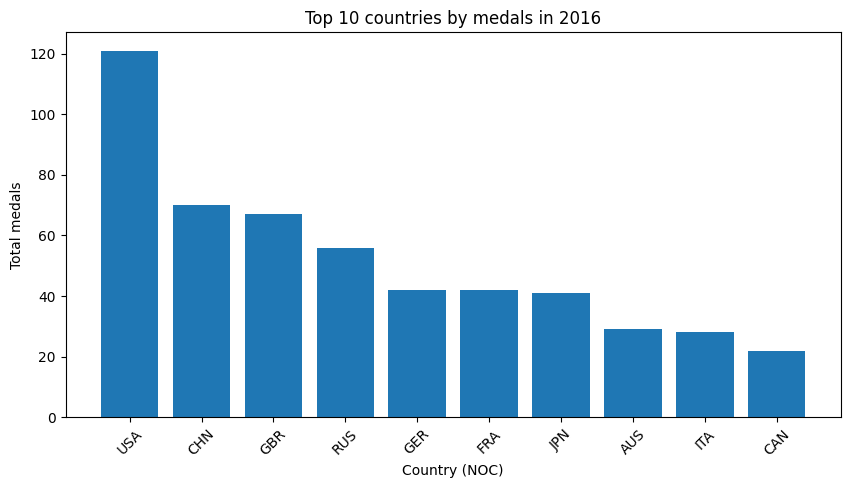

In [28]:
plt.figure(figsize=(10, 5))
plt.bar(plot_df["NOC"], plot_df["Total_Medals"])
plt.title(f"Top 10 countries by medals in {latest_year}")
plt.xlabel("Country (NOC)")
plt.ylabel("Total medals")
plt.xticks(rotation=45)
plt.show()

## Interpretation of initial visualization

The latest Olympic year available in the dataset is 2016.

The bar chart of the top 10 countries shows a clear dominance pattern:
a small number of countries win a disproportionately large number of medals.

This first visualization already suggests a key insight for the project:
Olympic success is not evenly distributed across countries.

In the next phase, I will explore this concentration more systematically.

In [29]:
country_year.to_csv("olympics_country_year.csv", index=False)
print("Export completed: olympics_country_year.csv")

Export completed: olympics_country_year.csv


In [30]:
from google.colab import files
files.download("olympics_country_year.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>